In [193]:
%matplotlib inline
import csv
import re
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

try:
    import pylandau
    _HAVE_PYLANDAU = True
except ImportError:
    _HAVE_PYLANDAU = False
try:
    from scipy.optimize import curve_fit
    from scipy.stats import moyal
    _HAVE_SCIPY = True
except ImportError:
    _HAVE_SCIPY = False

_BUILD = "2026-07-20a (multi-strip signal format, wfield plot, aclgad support)"
print(f"[analyze_scan.py build: {_BUILD}]")

[analyze_scan.py build: 2026-07-20a (multi-strip signal format, wfield plot, aclgad support)]


In [194]:
MODELS = ["vodm", "okuto", "massey", "grant"]
COLORS = {"vodm": "tab:red", "okuto": "tab:blue", "massey": "tab:green",
          "grant": "tab:orange"}
MARKERS = {"vodm": "o", "okuto": "s", "massey": "^", "grant": "D"}

_FLOAT_COLS = ["Epeak_line_Vcm", "Epeak_global_Vcm", "Ge", "GeSem", "Geh",
               "GehSem", "median", "F", "GeMedian"]
_INT_COLS = ["nCapEh", "N", "divergent"]
_STR_COLS = ["bias", "model"]

In [195]:
def load_results(path):
    with open(path, newline="") as f:
        rows = list(csv.DictReader(f))
    if not rows:
        raise ValueError(f"{path} has no data rows")
    d = {}
    for c in _STR_COLS:
        d[c] = np.array([r[c] for r in rows])
    for c in _FLOAT_COLS:
        d[c] = np.array([float(r[c]) if c in r and r[c] != ""
                         else np.nan for r in rows])
    for c in _INT_COLS:
        d[c] = np.array([int(r[c]) if c in r and r[c] != "" else 0
                         for r in rows])
    return d

def bias_float(s):
    try:
        return float(s)
    except (ValueError, TypeError):
        return np.nan

def discover_bias_folders(root):
    root = Path(root)
    out = {}
    if root.is_dir():
        for d in sorted(root.glob("output_files_*")):
            if not d.is_dir():
                continue
            m = re.search(r"([0-9]+(?:\.[0-9]+)?)V", d.name)
            if m:
                out[m.group(1)] = d
    if not out:
        out["NA"] = root
    return out

def load_results_multi(bias_folders):
    parts = []
    for bias, folder in bias_folders.items():
        path = Path(folder) / "results.csv"
        if not path.exists():
            print(f"no results.csv in {folder} -- skipping")
            continue
        parts.append(load_results(str(path)))
    if not parts:
        raise FileNotFoundError("no results.csv found in any bias folder")
    return {k: np.concatenate([p[k] for p in parts]) for k in parts[0]}

def model_rows(d, model):
    m = d["model"] == model
    if not m.any():
        return None
    bias = np.array([bias_float(b) for b in d["bias"][m]])
    finite = np.isfinite(bias)
    if not finite.any():
        return None
    bias = bias[finite]
    order = np.argsort(bias)
    out = {k: d[k][m][finite][order] for k in d}
    out["bias"] = bias[order]
    return out

In [225]:
DATA_ROOT = "./lgad.cpp-output"
ref_bias = "150"
landau_draws = 20000
seed = 0

bias_folders = discover_bias_folders(DATA_ROOT)
print(f"found {len(bias_folders)} bias folder(s): "
      f"{ {k: str(v) for k, v in bias_folders.items()} }")
d = load_results_multi(bias_folders)
print(f"loaded {len(d['bias'])} rows total, models: "
      f"{sorted(set(d['model']))}, biases: {sorted(set(d['bias']))}")

if ref_bias is None:
    biases = [b for b in d["bias"] if b != "NA"]
    ref_bias = max(biases, key=bias_float) if biases else d["bias"][0]
ref_folder = bias_folders.get(ref_bias, ".")
print(f"ref_bias (for the avalanche-statistics group) = {ref_bias} "
      f"(folder={ref_folder})")

found 3 bias folder(s): {'150': 'lgad.cpp-output\\output_files_150V', '180': 'lgad.cpp-output\\output_files_180V', '190': 'lgad.cpp-output\\output_files_190V'}
loaded 12 rows total, models: [np.str_('grant'), np.str_('massey'), np.str_('okuto'), np.str_('vodm')], biases: [np.str_('150'), np.str_('180'), np.str_('190')]
ref_bias (for the avalanche-statistics group) = 150 (folder=lgad.cpp-output\output_files_150V)


In [197]:
def plot_gain_vs_bias(d, outpath="gain_vs_bias.png"):
    if not any(model_rows(d, m) is not None for m in MODELS):
        print(f"skipping {outpath}: no rows with a parseable bias label "
              f"(this looks like a single ad-hoc run -- run_scan.sh over "
              f">=2 bias points to get a trend here)")
        return
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    for model in MODELS:
        r = model_rows(d, model)
        if r is None:
            continue
        c, mk = COLORS[model], MARKERS[model]
        ok = r["divergent"] == 0
        ax.errorbar(r["bias"][ok], r["Geh"][ok], yerr=r["GehSem"][ok],
                    marker=mk, ls="-", color=c, label=f"{model}  G_eh (mean)",
                    capsize=3)
        ax.plot(r["bias"][ok], r["median"][ok], marker=mk, ls=":", color=c,
                markersize=4, alpha=0.6, label=f"{model}  G_eh (median)")
        if (~ok).any():
            ax.scatter(r["bias"][~ok], np.full((~ok).sum(),
                       ax.get_ylim()[1] if ax.get_ylim()[1] > 1 else 1e3),
                       marker="^", color=c, s=90, zorder=5,
                       label=f"{model} divergent" if model not in
                       [l.get_label().split()[0] for l in ax.lines] else None)
        ax.plot(r["bias"], r["Ge"], marker=mk, ls="--", color=c,
                markersize=4, alpha=0.35)
    ax.set_yscale("log")
    ax.set_xlabel("bias [V]")
    ax.set_ylabel("gain")
    ax.set_title("Gain vs bias  (solid = G_eh mean, dotted = median,\n"
                 "faint dashed = G_e, triangle = feedback-divergent)")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()
    print("wrote", outpath)

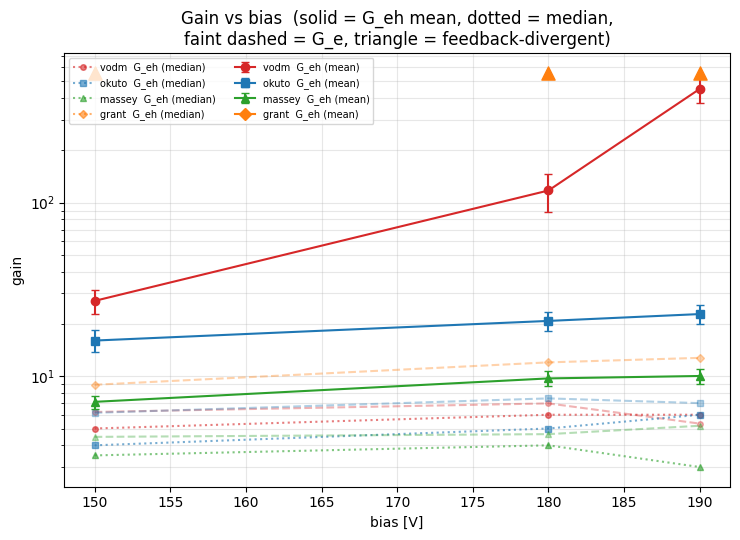

wrote gain_vs_bias.png


In [198]:
plot_gain_vs_bias(d)

In [199]:
def plot_excess_noise_vs_gain(d, outpath="excess_noise_vs_gain.png"):
    fig, ax = plt.subplots(figsize=(7, 5.5))
    for model in MODELS:
        sel = d["model"] == model
        if not sel.any():
            continue
        c, mk = COLORS[model], MARKERS[model]
        ok = d["divergent"][sel] == 0
        ax.scatter(d["Geh"][sel][ok], d["F"][sel][ok], color=c, marker=mk,
                  s=50, label=model, zorder=3)
        if (~ok).any():
            ax.scatter(d["Geh"][sel][~ok], d["F"][sel][~ok], color=c,
                      marker=mk, s=50, facecolors="none", zorder=3)
    gmax = max(1, np.nanmax(d["Geh"])) * 1.2
    g = np.logspace(0, np.log10(gmax), 200)
    fvals = d["F"][np.isfinite(d["F"]) & (d["F"] > 0)]
    ylo, yhi = (0.7 * fvals.min(), 3. * fvals.max()) if len(fvals) \
        else (0.5, 20.)
    g_label = gmax ** 0.6
    for k in (0.02, 0.1, 0.3, 0.5, 1.0):
        F = k * g + (2 - 1. / g) * (1 - k)
        ax.plot(g, F, color="gray", lw=0.8, alpha=0.6)
        F_label = k * g_label + (2 - 1. / g_label) * (1 - k)
        if ylo < F_label < yhi:
            ax.annotate(f"k={k}", (g_label, F_label), fontsize=7,
                       color="gray", ha="center", va="bottom")
    ax.set_xscale("log")
    ax.set_yscale("log")
    if len(fvals):
        ax.set_ylim(ylo, yhi)
    ax.set_xlabel("G_eh")
    ax.set_ylabel("excess noise factor F = <G^2>/<G>^2")
    ax.set_title("Excess noise vs gain, with McIntyre F(G;k) reference curves")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()
    print("wrote", outpath)

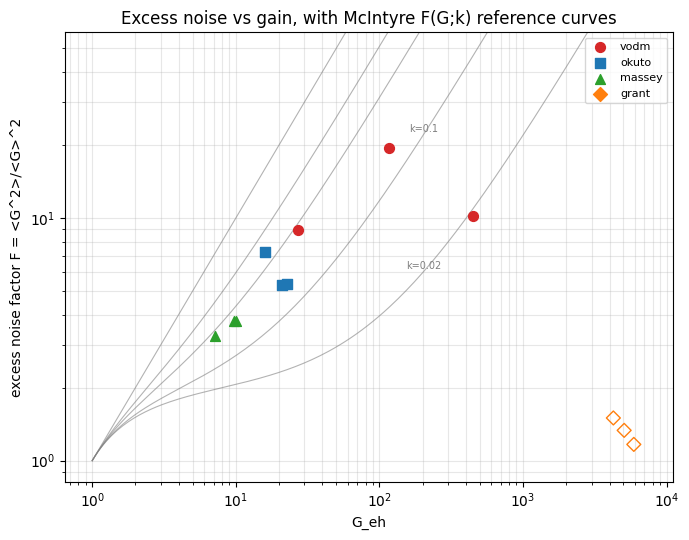

wrote excess_noise_vs_gain.png


In [200]:
plot_excess_noise_vs_gain(d)

In [201]:
def plot_gain_vs_field(d, outpath="gain_vs_field.png"):
    if not any(model_rows(d, m) is not None for m in MODELS):
        print(f"skipping {outpath}: no rows with a parseable bias label")
        return
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    for model in MODELS:
        r = model_rows(d, model)
        if r is None:
            continue
        c, mk = COLORS[model], MARKERS[model]
        field = r["Epeak_line_Vcm"] / 1e5
        ok = r["divergent"] == 0
        ax.errorbar(field[ok], r["Geh"][ok], yerr=r["GehSem"][ok],
                    marker=mk, ls="-", color=c, label=f"{model} G_eh",
                    capsize=3)
        ax.plot(field, r["Ge"], marker=mk, ls="--", color=c, markersize=4,
                alpha=0.35)
    ax.set_yscale("log")
    ax.set_xlabel("E_peak (line probe) [x1e5 V/cm]")
    ax.set_ylabel("gain")
    ax.set_title("Gain vs peak field  (solid = G_eh, faint dashed = G_e)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()
    print("wrote", outpath)

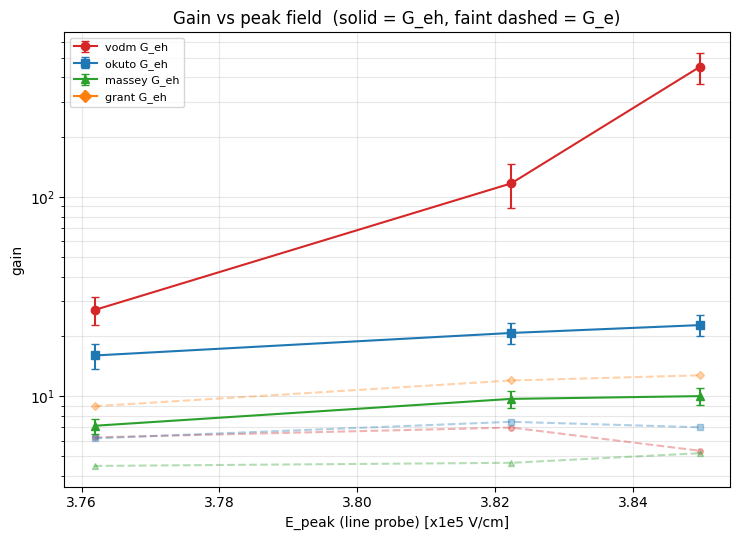

wrote gain_vs_field.png


In [202]:
plot_gain_vs_field(d)

In [203]:
def plot_avalanche_stats(models, ref_bias, folder=".", outpath=None):
    outpath = outpath or f"avalanche_stats_{ref_bias}V.png"
    data = {m: load_sizes(m, ref_bias, folder) for m in models}
    data = {m: v for m, v in data.items() if v is not None and len(v) > 0}
    if not data:
        print(f"no eh_sizes files found for bias={ref_bias}V -- skipping "
              f"{outpath}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    ax = axes[0]
    for m, v in data.items():
        vs = np.sort(v)
        cdf = np.arange(1, len(vs) + 1) / len(vs)
        ax.plot(vs, cdf, color=COLORS[m], label=m)
    ax.set_xscale("log")
    ax.set_xlabel("avalanche size G_eh")
    ax.set_ylabel("cumulative fraction")
    ax.set_title(f"CDF @ {ref_bias} V")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[1]
    labels = list(data.keys())
    try:
        ax.boxplot([data[m] for m in labels], tick_labels=labels,
                  showfliers=True,
                  flierprops=dict(marker=".", markersize=2, alpha=0.3))
    except TypeError:
        ax.boxplot([data[m] for m in labels], labels=labels,
                  showfliers=True,
                  flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_yscale("log")
    ax.set_ylabel("avalanche size G_eh")
    ax.set_title(f"Box plot @ {ref_bias} V (log scale)")
    ax.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()
    print("wrote", outpath)

In [204]:
plot_avalanche_stats(MODELS, ref_bias, ref_folder)

no eh_sizes files found for bias=aclgadV -- skipping avalanche_stats_aclgadV.png


In [ ]:
def load_signal(bias, folder="."):
    for fname in (f"signal_{bias}V.csv", "signal_pad.csv"):
        p = Path(folder) / fname
        if p.exists():
            return np.genfromtxt(p, delimiter=",", names=True)
    return None

def plot_signal(bias, folder=".", outpath=None):
    outpath = outpath or f"signal_{bias}V.png"
    d = load_signal(bias, folder)
    if d is None:
        print(f"no signal file for bias={bias}V -- skipping {outpath}")
        return

    names = d.dtype.names
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    if "i_gainON" in names:
        ax = axes[0]
        ax.plot(d["t_ns"], d["i_gainON"], color="tab:red", lw=1.5,
               label="gain ON")
        ax.plot(d["t_ns"], d["i_gainOFF"], color="tab:blue", lw=1.5,
               label="gain OFF")
        ax.set_xlabel("t [ns]")
        ax.set_ylabel("induced current [arb.]")
        ax.set_title(f"Signal waveform @ {bias} V")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

        ax = axes[1]
        peakOn = np.max(np.abs(d["i_gainON"]))
        peakOff = np.max(np.abs(d["i_gainOFF"]))
        normOn = d["i_gainON"] / peakOn if peakOn > 0 else d["i_gainON"]
        normOff = d["i_gainOFF"] / peakOff if peakOff > 0 else d["i_gainOFF"]
        ax.plot(d["t_ns"], normOn, color="tab:red", lw=1.5,
               label=f"gain ON (peak={peakOn:.3g})")
        ax.plot(d["t_ns"], normOff, color="tab:blue", lw=1.5,
               label=f"gain OFF (peak={peakOff:.3g})")
        ax.set_xlabel("t [ns]")
        ax.set_ylabel("current / own peak")
        ax.set_title(f"Shape comparison @ {bias} V")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    else:
        strips = sorted({c[:-3] for c in names if c.endswith("_ON")})
        if not strips:
            print(f"signal file for bias={bias}V has neither i_gainON nor "
                  f"strip*_ON columns -- skipping {outpath}")
            plt.close(fig)
            return
        cmap = plt.get_cmap("tab10")
        for ax, suffix, ttl in [(axes[0], "_ON", "gain ON"),
                                 (axes[1], "_OFF", "gain OFF (reference)")]:
            for k, s in enumerate(strips):
                ax.plot(d["t_ns"], d[s + suffix], color=cmap(k), lw=1.5,
                       label=s)
            ax.set_xlabel("t [ns]")
            ax.set_ylabel("induced current [arb.]")
            ax.set_title(f"Per-strip signal, {ttl} @ {bias} V")
            ax.legend(fontsize=9)
            ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    print("wrote", outpath)

In [224]:
plot_signal(ref_bias, ref_folder)

no signal file for bias=aclgadV -- skipping signal_aclgadV.png


In [207]:
def load_wfield(bias, folder="./lgad.cpp-output"):
    for fname in (f"wfield_full.csv", "wfield_full.csv"):
        p = Path(folder) / fname
        if p.exists():
            d = np.genfromtxt(p, delimiter=",", names=True)
            strips = [c for c in d.dtype.names if c.endswith("_phi")]
            x = np.unique(d["x_um"])
            y = np.unique(d["y_um"])
            nx, ny = len(x), len(y)
            phi = {}
            for s in strips:
                grid = d[s].reshape(nx, ny).T
                phi[s.replace("_phi", "")] = grid
            return x, y, phi
    return None

def plot_wfield(bias, folder=".", outpath=None):
    outpath = outpath or f"wfield_{bias}V.png"
    data = load_wfield(bias, folder)
    if data is None:
        print(f"no wfield_full file for bias={bias}V -- skipping {outpath}")
        return
    x, y, phi = data
    names = list(phi.keys())
    fig, ax = plt.subplots(figsize=(11, 4.5))
    combined = np.maximum.reduce([phi[n] for n in names])
    im = ax.pcolormesh(x, y, combined, shading="auto", cmap="viridis")
    plt.colorbar(im, ax=ax, label="weighting potential (max over strips)")
    ax.set_xlabel("x [um]")
    ax.set_ylabel("y [um]")
    ax.set_title(f"Weighting potential @ {bias} V (Garfield's own values, "
                f"{len(names)} strips)")
    plt.tight_layout()
    plt.show()
    print("wrote", outpath)

In [208]:
plot_wfield(ref_bias, ref_folder)

no wfield_full file for bias=aclgadV -- skipping wfield_aclgadV.png


In [209]:
def plot_alpha_relative(d, outpath="alpha_relative.png"):
    if not any(model_rows(d, m) is not None for m in MODELS):
        print(f"skipping {outpath}: no rows with a parseable bias label")
        return
    fig, ax = plt.subplots(figsize=(7, 5.5))
    for model in MODELS:
        r = model_rows(d, model)
        if r is None:
            continue
        c, mk = COLORS[model], MARKERS[model]
        field = r["Epeak_line_Vcm"] / 1e5
        ax.plot(field, np.log(np.clip(r["Ge"], 1e-3, None)), marker=mk,
                color=c, label=model)
    ax.set_xlabel("E_peak (line probe) [x1e5 V/cm]")
    ax.set_ylabel("ln(G_e)  ~  integral of alpha_e over the gain layer")
    ax.set_title("Empirical relative ionisation strength by model\n"
                 "(from your own G_e data -- see script docstring)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("wrote", outpath)

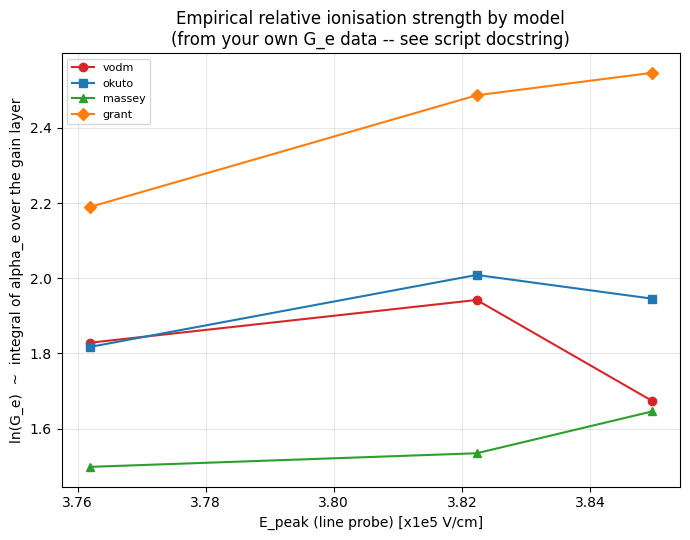

wrote alpha_relative.png


In [210]:
plot_alpha_relative(d)

In [211]:
def load_primaries(bias, folder="."):
    for fname in (f"primary_pairs_{bias}V.txt", "primary_pairs.txt"):
        p = Path(folder) / fname
        if p.exists():
            return np.loadtxt(p)
    return None

def landau_convolution(primary_counts, gain_samples, n_draws, rng):
    tracks = rng.choice(primary_counts, size=n_draws).astype(int)
    out = np.empty(n_draws)
    for n in np.unique(tracks):
        idx = np.where(tracks == n)[0]
        if n <= 0:
            out[idx] = 0.
            continue
        draws = rng.choice(gain_samples, size=(len(idx), n), replace=True)
        out[idx] = draws.sum(axis=1)
    return out

def fit_langau(charge, bins=80):
    if len(charge) < 20:
        return None
    counts, edges = np.histogram(charge, bins=bins, density=True)
    centers = 0.5 * (edges[1:] + edges[:-1])
    mpv0 = centers[np.argmax(counts)]
    q75, q25 = np.percentile(charge, [75, 25])
    spread0 = max((q75 - q25) / 2, 1e-6)

    if _HAVE_PYLANDAU and _HAVE_SCIPY:
        p0 = [mpv0, spread0 * 0.5, spread0 * 0.3, counts.max()]
        try:
            popt, pcov = curve_fit(
                lambda x, mpv, eta, sigma, A: pylandau.langau(x, mpv, eta,
                                                               sigma, A),
                centers, counts, p0=p0, maxfev=20000,
                bounds=([0, 1e-3, 1e-3, 0], [np.inf, np.inf, np.inf, np.inf]))
        except RuntimeError:
            return None
        perr = np.sqrt(np.diag(pcov))
        return {"mpv": popt[0], "mpv_err": perr[0], "width": popt[1],
                "curve": lambda x: pylandau.langau(x, *popt),
                "centers": centers, "counts": counts,
                "method": "Landau (x) Gauss fit (pylandau)"}
    elif _HAVE_SCIPY:
        try:
            loc, scale = moyal.fit(charge, loc=mpv0, scale=spread0)
        except Exception:
            return None
        return {"mpv": loc, "mpv_err": np.nan, "width": scale,
                "curve": lambda x: moyal.pdf(x, loc, scale),
                "centers": centers, "counts": counts,
                "method": "Moyal approximation (scipy; pylandau not "
                          "installed -- pip install pylandau for a true "
                          "Landau x Gauss fit)"}
    return None

def plot_mip_landau(models, ref_bias, n_draws, rng, folder=".", outpath=None):
    outpath = outpath or f"mip_landau_{ref_bias}V.png"
    primaries = load_primaries(ref_bias, folder)
    if primaries is None:
        print(f"no primary_pairs file for bias={ref_bias}V -- skipping "
              f"{outpath}")
        return
    if not (_HAVE_PYLANDAU or _HAVE_SCIPY):
        print("neither pylandau nor scipy available -- install one of "
              "them for a Landau fit (falling back to histogram only)")
    fig, ax = plt.subplots(figsize=(9, 6.5))
    for m in models:
        sizes = load_sizes(m, ref_bias, folder)
        if sizes is None:
            continue
        charge = landau_convolution(primaries, sizes, n_draws, rng)
        ax.hist(charge, bins=80, histtype="step", lw=1.3, color=COLORS[m],
               density=True, alpha=0.5)
        fit = fit_langau(charge)
        if fit is None:
            print(f"{m}: no Landau fit (too little data or fit did not "
                  f"converge) -- histogram only")
            continue
        xf = np.linspace(charge.min(), charge.max(), 400)
        errtxt = f"+-{fit['mpv_err']:.2g}" if np.isfinite(fit["mpv_err"]) \
            else ""
        ax.plot(xf, fit["curve"](xf), color=COLORS[m], lw=2.2,
               label=f"{m}  MPV={fit['mpv']:.3g}{errtxt}  "
                     f"width={fit['width']:.2g}")
        model_at_centers = fit["curve"](fit["centers"])
        resid_frac = np.max(np.abs(fit["counts"] - model_at_centers)) \
            / fit["counts"].max()
        if resid_frac > 0.25:
            print(f"{m}: fit residual {resid_frac:.0%} of peak height "
                  f"({fit['method']}) -- likely too few underlying Heed "
                  f"tracks in primary_pairs.txt for a smooth tail, not "
                  f"necessarily a bad fit; consider raising nHeedTracks")
    ax.set_xlabel("collected charge [electrons]")
    ax.set_ylabel("probability density")
    ax.set_title(f"MIP collected-charge distribution @ {ref_bias} V\n"
                f"histogram = {n_draws} fast MC draws; curve = fitted "
                f"Landau shape (see console for fit method/quality)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    print("wrote", outpath)

In [212]:
rng = np.random.default_rng(seed)
plot_mip_landau(MODELS, ref_bias, landau_draws, rng, ref_folder)

no primary_pairs file for bias=aclgadV -- skipping mip_landau_aclgadV.png


In [213]:
def landau_charges_normalized(models, ref_bias, n_draws, rng, folder="."):
    primaries = load_primaries(ref_bias, folder)
    if primaries is None:
        return None
    out = {}
    for m in models:
        sizes = load_sizes(m, ref_bias, folder)
        if sizes is None:
            continue
        charge = landau_convolution(primaries, sizes, n_draws, rng)
        med = np.median(charge)
        out[m] = {"raw": charge,
                  "norm": charge / med if med > 0 else charge,
                  "median": med}
    return out

In [214]:
charges = landau_charges_normalized(MODELS, ref_bias, landau_draws, rng, ref_folder)

In [215]:
def plot_landau_hist_median(charges, ref_bias, outpath=None):
    outpath = outpath or f"landau_hist_median_{ref_bias}V.png"
    if not charges:
        print(f"no MIP-charge data -- skipping {outpath}")
        return
    fig, ax = plt.subplots(figsize=(9, 6.5))
    for m, c in charges.items():
        ax.hist(c["norm"], bins=80, histtype="step", lw=2.2, color=COLORS[m],
               density=True, label=f"{m}: median={c['median']:.3g} e-")
    ax.axvline(1.0, color="k", ls="--", lw=1, alpha=0.5, label="median (x=1)")
    ax.set_xlabel("collected charge / model median", fontsize=12)
    ax.set_ylabel("probability density", fontsize=12)
    ax.set_title(f"Landau distribution by model, centered on median @ "
                f"{ref_bias} V", fontsize=14)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("wrote", outpath)

In [216]:
plot_landau_hist_median(charges, ref_bias)

no MIP-charge data -- skipping landau_hist_median_aclgadV.png


In [217]:
def plot_charge_vs_bias_per_model(model, bias_folders, n_draws, rng,
                                   outpath=None):
    outpath = outpath or f"charge_{model}_vs_bias.png"
    biases = sorted(bias_folders.keys(), key=bias_float)
    cmap = plt.get_cmap("viridis")
    colors = cmap(np.linspace(0.15, 0.85, max(len(biases), 1)))
    fig, ax = plt.subplots(figsize=(8, 5.5))
    any_data = False
    for color, bias in zip(colors, biases):
        folder = bias_folders[bias]
        primaries = load_primaries(bias, folder)
        sizes = load_sizes(model, bias, folder)
        if primaries is None or sizes is None:
            continue
        any_data = True
        charge = landau_convolution(primaries, sizes, n_draws, rng)
        fit = fit_langau(charge)
        label = f"{bias} V"
        if fit is not None:
            label += f"  MPV={fit['mpv']:.3g}"
        ax.hist(charge, bins=80, histtype="step", lw=1.3, color=color,
               density=True, alpha=0.6, label=label)
        if fit is not None:
            xf = np.linspace(charge.min(), charge.max(), 400)
            ax.plot(xf, fit["curve"](xf), color=color, lw=2.2)
    if not any_data:
        print(f"{model}: no data at any bias -- skipping {outpath}")
        plt.close(fig)
        return
    ax.set_xlabel("collected charge [electrons]")
    ax.set_ylabel("probability density")
    ax.set_title(f"{model}: collected-charge distribution vs bias")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("wrote", outpath)

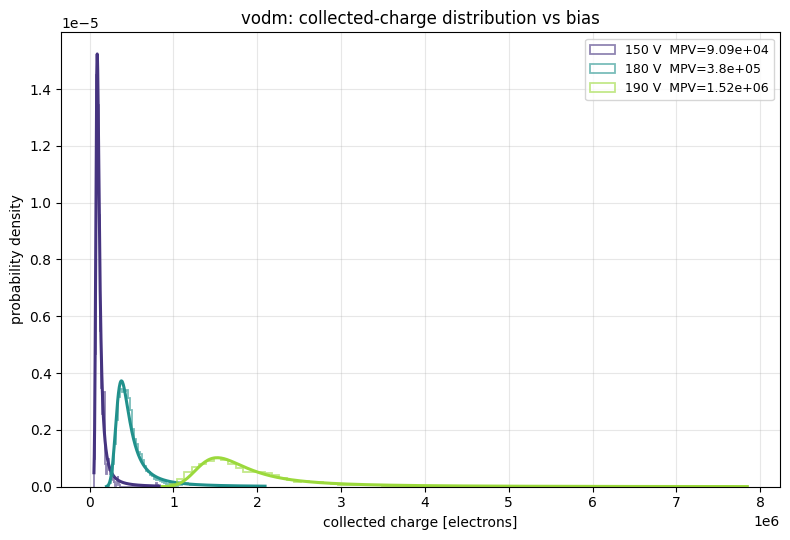

wrote charge_vodm_vs_bias.png


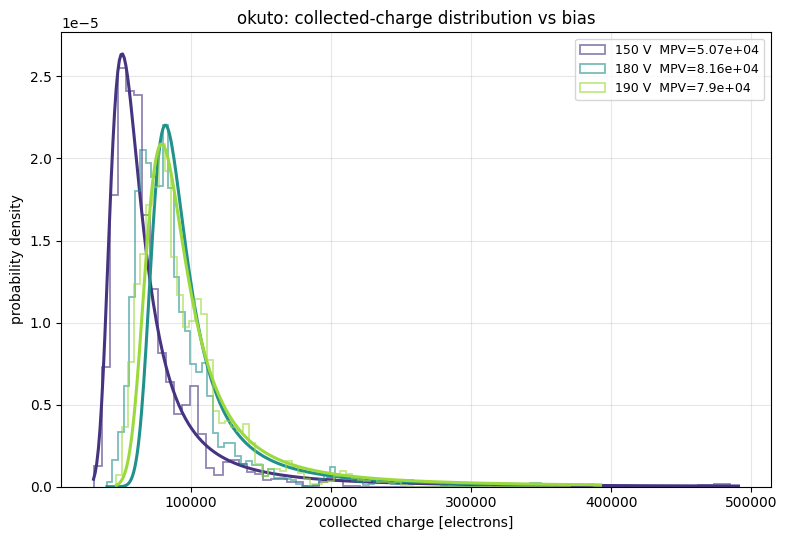

wrote charge_okuto_vs_bias.png


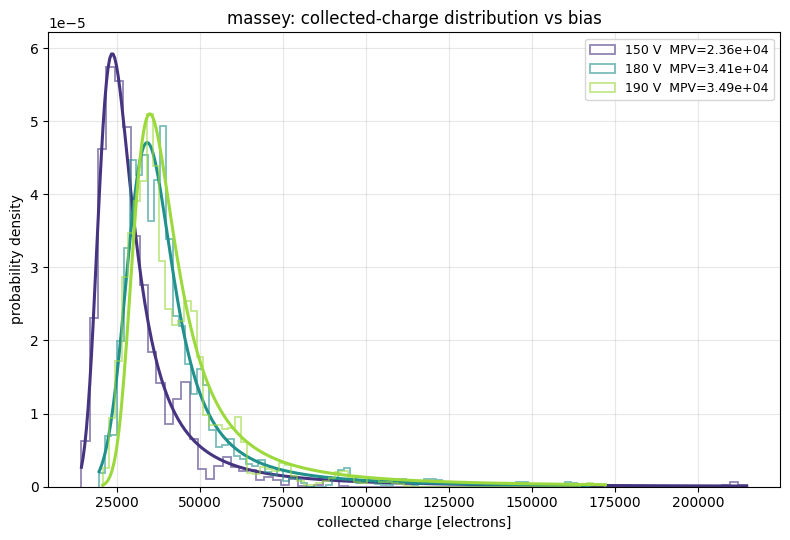

wrote charge_massey_vs_bias.png


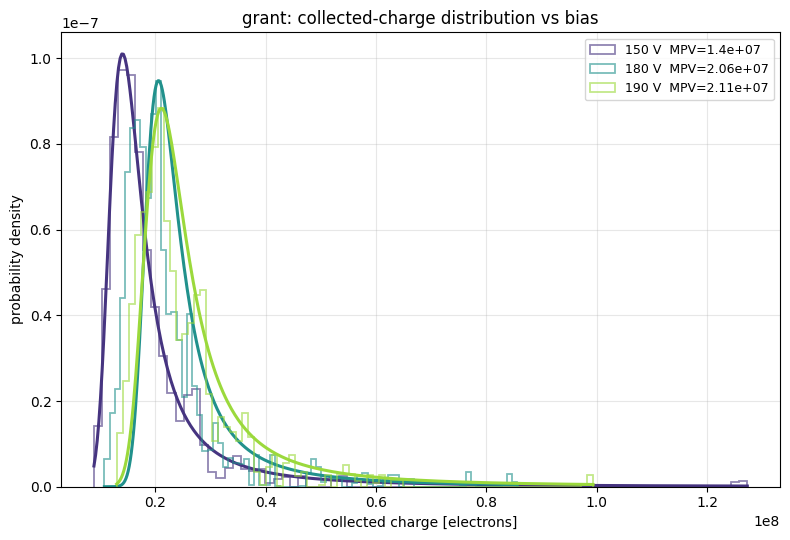

wrote charge_grant_vs_bias.png


In [218]:
for _m in MODELS:
    plot_charge_vs_bias_per_model(_m, bias_folders, landau_draws, rng)

In [226]:
def load_overlay(bias, folder="."):
    for fname in (f"signal_overlay_{bias}V.csv", f"signal_overlay{bias}V.csv",
                  "signal_overlay.csv"):
        p = Path(folder) / fname
        if not p.exists():
            continue
        with open(p) as f:
            lines = f.read().splitlines()
        if not lines:
            print(f"{fname}: empty file -- skipping")
            return None
        header = lines[0].split(",")
        ncols = len(header)
        if "time_ns" not in header:
            print(f"{fname}: no 'time_ns' column in header -- skipping")
            return None
        t_idx = header.index("time_ns")
        trk_idx = [i for i, c in enumerate(header) if c.startswith("trk")]
        if not trk_idx:
            print(f"{fname}: no 'trkN' columns in header -- skipping")
            return None

        start = 1
        if len(lines) > 1 and lines[1].startswith("nPairs"):
            start = 2

        t_list, sig_rows = [], []
        n_bad, examples = 0, []
        for ln in lines[start:]:
            if not ln.strip():
                n_bad += 1
                continue
            parts = ln.split(",")
            if len(parts) != ncols:
                n_bad += 1
                if len(examples) < 3:
                    examples.append(ln[:80])
                continue
            try:
                vals = [float(x) for x in parts]
            except ValueError:
                n_bad += 1
                if len(examples) < 3:
                    examples.append(ln[:80])
                continue
            if not np.isfinite(vals[t_idx]):
                n_bad += 1
                continue
            t_list.append(vals[t_idx])
            sig_rows.append([vals[i] for i in trk_idx])

        if n_bad:
            print(f"WARNING: {fname}: {n_bad} malformed/unparseable row(s) "
                  f"skipped" + (f" (examples: {examples})" if examples else "")
                  + " -- inspect the raw file, it may be corrupted or "
                    "partially written")
        if not t_list:
            print(f"{fname}: no valid data rows after cleaning -- skipping")
            return None
        return np.array(t_list), np.array(sig_rows)
    return None

def overlay_charges_electrons(t, sig):
    _trap = getattr(np, "trapezoid", None) or np.trapz
    q_fc = np.array([-_trap(sig[:, k], t) for k in range(sig.shape[1])])
    return q_fc / 1.602e-4

def load_overlay_pairs(bias, folder=".", ntrk=None):
    for fname in (f"overlay_summary_{bias}V.csv", "overlay_summary.csv"):
        p = Path(folder) / fname
        if p.exists():
            d = np.genfromtxt(p, delimiter=",", names=True)
            order = np.argsort(d["track"])
            pairs = d["nPairs"][order]
            if ntrk is not None and len(pairs) != ntrk:
                print(f"overlay_summary track count ({len(pairs)}) != "
                      f"signal_overlay track count ({ntrk}) -- ignoring "
                      f"nPairs, gain will not be computed")
                return None
            return pairs
    for fname in (f"signal_overlay_{bias}V.csv", f"signal_overlay{bias}V.csv",
                  "signal_overlay.csv"):
        p = Path(folder) / fname
        if p.exists():
            with open(p) as f:
                f.readline()
                second = f.readline()
            if second.startswith("nPairs"):
                try:
                    pairs = np.array([float(v) for v in
                                      second.strip().split(",")[1:]])
                except ValueError:
                    print(f"{fname}: nPairs row has unparseable values -- "
                          f"ignoring nPairs, gain will not be computed")
                    return None
                if ntrk is not None and len(pairs) != ntrk:
                    print(f"embedded nPairs count ({len(pairs)}) != track "
                          f"count ({ntrk}) -- ignoring nPairs")
                    return None
                return pairs
            break
    return None

def plot_overlay(bias, folder=".", outpath=None):
    outpath = outpath or f"signal_overlay_{bias}V.png"
    data = load_overlay(bias, folder)
    if data is None:
        print(f"no signal_overlay file for bias={bias}V -- skipping "
              f"{outpath}")
        return None, None
    t, sig = data
    ntrk = sig.shape[1]
    charges = overlay_charges_electrons(t, sig)
    pairs = load_overlay_pairs(bias, folder, ntrk)
    gains = charges / pairs if pairs is not None else None

    bad = [k for k in range(ntrk)
           if not np.isfinite(sig[:, k]).all() or np.allclose(sig[:, k], 0)]
    if bad:
        print(f"WARNING: {len(bad)} corrupted/empty track column(s): "
              f"{bad} -- possible thread-safety issue in the overlay run")
    print(f"overlay {bias}V: {ntrk} tracks, per-track charge "
          f"median={np.median(charges):.3g} e-, mean={charges.mean():.3g} "
          f"e-, min={charges.min():.3g}, max={charges.max():.3g}")
    if gains is not None:
        print(f"overlay {bias}V: per-track gain (charge/nPairs) "
              f"median={np.median(gains):.4g}  mean={gains.mean():.4g}  "
              f"+-{gains.std():.4g}  min={gains.min():.4g}  "
              f"max={gains.max():.4g}")
    else:
        print(f"no overlay_summary[_{bias}V].csv found -- per-track gain "
              f"not computed (add 'track,nPairs' export to the overlay "
              f"program to enable this)")

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))
    ax = axes[0]
    for k in range(ntrk):
        ax.plot(t, sig[:, k], color="tab:blue", lw=0.7, alpha=0.25)
    ax.plot(t, sig.mean(axis=1), color="tab:red", lw=2.2,
           label=f"mean of {ntrk} tracks")
    ax.set_xlabel("t [ns]")
    ax.set_ylabel("induced current [fC/ns = uA]")
    ax.set_title(f"MIP waveform overlay @ {bias} V ({ntrk} full-sim tracks)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    ax = axes[1]
    nbins = max(10, min(30, ntrk // 3))
    ax.hist(charges, bins=nbins, histtype="step", lw=1.8,
           color="tab:blue", density=True,
           label=f"{ntrk} tracks (full sim)")
    fit = fit_langau(charges, bins=nbins)
    if fit is not None:
        xf = np.linspace(charges.min(), charges.max(), 400)
        errtxt = f"+-{fit['mpv_err']:.2g}" if np.isfinite(fit["mpv_err"]) \
            else ""
        ax.plot(xf, fit["curve"](xf), color="tab:red", lw=2.2,
               label=f"langau fit: MPV={fit['mpv']:.3g}{errtxt} e-")
    ax.axvline(np.median(charges), color="k", ls="--", lw=1, alpha=0.5,
              label=f"median={np.median(charges):.3g} e-")
    ax.set_xlabel("collected charge [electrons]")
    ax.set_ylabel("probability density")
    ax.set_title("Per-track collected charge (true Landau, full sim)")
    if gains is not None:
        ax.text(0.97, 0.97,
               f"gain = charge / nPairs\nmedian={np.median(gains):.3g}  "
               f"mean={gains.mean():.3g}+-{gains.std():.2g}",
               transform=ax.transAxes, ha="right", va="top", fontsize=8,
               bbox=dict(boxstyle="round", fc="white", alpha=0.8))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    print("wrote", outpath)
    return charges, gains

overlay 150V: 200 tracks, per-track charge median=4.78e+04 e-, mean=5.28e+04 e-, min=1.81e+04, max=1.77e+05
overlay 150V: per-track gain (charge/nPairs) median=11.77  mean=11.76  +-0.3713  min=10.73  max=12.55


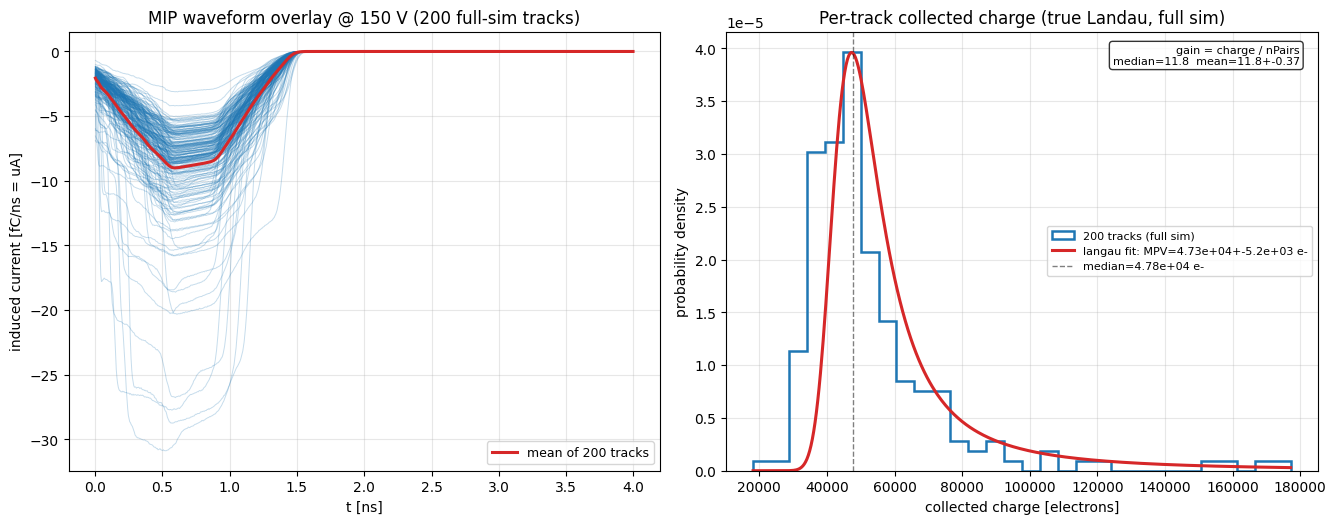

wrote signal_overlay_150V.png


In [227]:
overlay_charges, overlay_gains = plot_overlay(ref_bias, ref_folder)

In [228]:
def plot_overlay_validation(bias, model, n_draws, rng, folder=".",
                            outpath=None):
    outpath = outpath or f"overlay_validation_{bias}V.png"
    data = load_overlay(bias, folder)
    primaries = load_primaries(bias, folder)
    sizes = load_sizes(model, bias, folder)
    if data is None or primaries is None or sizes is None:
        missing = [n for n, v in [("signal_overlay", data),
                                  ("primary_pairs", primaries),
                                  (f"eh_sizes_{model}", sizes)] if v is None]
        print(f"overlay validation needs {missing} for bias={bias}V -- "
              f"skipping {outpath}")
        return
    t, sig = data
    full = overlay_charges_electrons(t, sig)
    fast = landau_convolution(primaries, sizes, n_draws, rng)

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    nb = max(10, min(30, len(full) // 3))
    ax.hist(fast, bins=60, histtype="stepfilled", alpha=0.3,
           color="tab:orange", density=True,
           label=f"fast convolution ({n_draws} draws, {model})")
    ax.hist(full, bins=nb, histtype="step", lw=2.0, color="tab:blue",
           density=True, label=f"full simulation ({len(full)} tracks)")
    ax.axvline(np.median(fast), color="tab:orange", ls="--", lw=1.2,
              label=f"conv median={np.median(fast):.3g}")
    ax.axvline(np.median(full), color="tab:blue", ls="--", lw=1.2,
              label=f"full-sim median={np.median(full):.3g}")
    ratio = np.median(full) / np.median(fast) if np.median(fast) > 0 \
        else np.nan
    ax.set_xlabel("collected charge [electrons]")
    ax.set_ylabel("probability density")
    ax.set_title(f"Fast convolution vs full simulation @ {bias} V "
                f"(median ratio full/conv = {ratio:.3f})")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("wrote", outpath,
          f"-- median ratio full/conv = {ratio:.3f} "
          f"(1.0 = fast method validated at median level)")

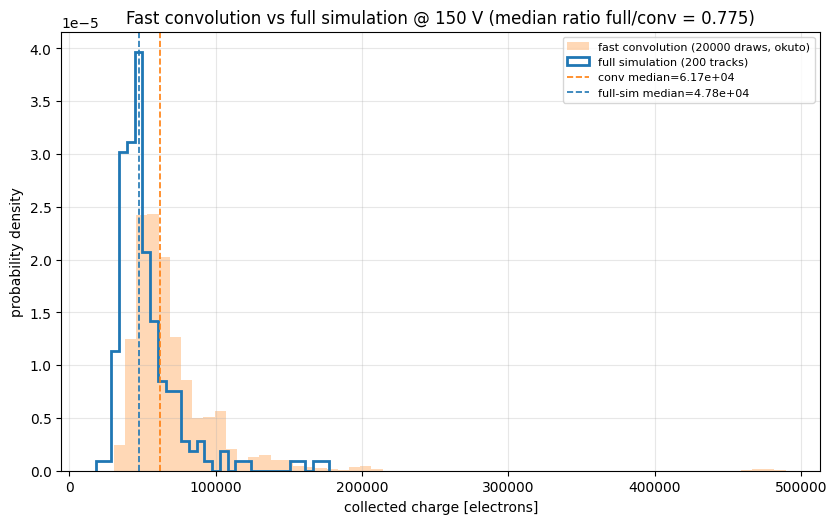

wrote overlay_validation_150V.png -- median ratio full/conv = 0.775 (1.0 = fast method validated at median level)


In [229]:
plot_overlay_validation(ref_bias, "okuto", landau_draws, rng, ref_folder)